In [8]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords

# Download required NLTK data
nltk.download("punkt")
nltk.download("stopwords")

print("✅ TruthLens libraries loaded successfully!")

✅ TruthLens libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
print("=" * 60)
print("🔍 TRUTHLENS - REAL-TIME NEWS TEXT ANALYZER")
print("=" * 60)

news_text = input("\n📝 Enter or paste your news article:\n\n")

if news_text.strip():
    print("\n✅ News received successfully!")
else:
    print("\n⚠️ Please enter some news text.")

🔍 TRUTHLENS - REAL-TIME NEWS TEXT ANALYZER



📝 Enter or paste your news article:

 Scientists have developed a new technology that could improve clean energy production. Researchers tested the system in several experiments and reported promising results. The team plans to conduct more studies before the technology is widely used.



✅ News received successfully!


In [10]:
# Clean the text
clean_text = re.sub(r"\s+", " ", news_text).strip()

# Find words
words = re.findall(r"\b[a-zA-Z]+\b", clean_text)

# Count words
word_count = len(words)

# Find sentences
sentences = re.split(r"[.!?]+", clean_text)
sentences = [s.strip() for s in sentences if s.strip()]

# Count sentences
sentence_count = len(sentences)

# Count characters
character_count = len(clean_text)

# Average word length
if word_count > 0:
    average_word_length = sum(len(word) for word in words) / word_count
else:
    average_word_length = 0

print("=" * 50)
print("📊 TEXT ANALYSIS")
print("=" * 50)

print(f"📝 Word count          : {word_count}")
print(f"📄 Sentence count      : {sentence_count}")
print(f"🔤 Character count     : {character_count}")
print(f"📏 Average word length : {average_word_length:.2f}")

📊 TEXT ANALYSIS
📝 Word count          : 36
📄 Sentence count      : 3
🔤 Character count     : 248
📏 Average word length : 5.83


In [11]:
# ==========================================
# CELL 5 - SENTIMENT ANALYSIS
# ==========================================

blob = TextBlob(clean_text)

# Get sentiment values
polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity

# Determine sentiment
if polarity > 0.1:
    sentiment = "Positive 😊"
elif polarity < -0.1:
    sentiment = "Negative 😞"
else:
    sentiment = "Neutral 😐"

print("=" * 50)
print("😊 SENTIMENT ANALYSIS")
print("=" * 50)

print(f"Sentiment    : {sentiment}")
print(f"Polarity     : {polarity:.2f}")
print(f"Subjectivity : {subjectivity:.2f}")

😊 SENTIMENT ANALYSIS
Sentiment    : Positive 😊
Polarity     : 0.17
Subjectivity : 0.41


In [12]:
# ==========================================
# CELL 6 - KEYWORD EXTRACTION
# ==========================================

# Get English stopwords
stop_words = set(stopwords.words("english"))

# Convert all words to lowercase
lower_words = [word.lower() for word in words]

# Remove common words
keywords = [
    word
    for word in lower_words
    if word not in stop_words and len(word) > 2
]

# Count keyword frequency
keyword_counts = Counter(keywords)

# Get top 10 keywords
top_keywords = keyword_counts.most_common(10)

print("=" * 50)
print("🔑 TOP KEYWORDS")
print("=" * 50)

if top_keywords:
    for number, (word, count) in enumerate(top_keywords, start=1):
        print(f"{number}. {word} → {count} time(s)")
else:
    print("No keywords found.")

🔑 TOP KEYWORDS
1. technology → 2 time(s)
2. scientists → 1 time(s)
3. developed → 1 time(s)
4. new → 1 time(s)
5. could → 1 time(s)
6. improve → 1 time(s)
7. clean → 1 time(s)
8. energy → 1 time(s)
9. production → 1 time(s)
10. researchers → 1 time(s)


In [13]:
# ==========================================
# CELL 7 - TRUTHLENS SUSPICION ANALYSIS
# ==========================================

# Words/phrases that can indicate sensational language
suspicious_words = [
    "shocking",
    "breaking",
    "unbelievable",
    "miracle",
    "secret",
    "urgent",
    "exposed",
    "scandal",
    "danger",
    "warning",
    "guaranteed",
    "viral",
    "incredible",
    "you won't believe",
    "must see"
]

text_lower = clean_text.lower()

# Find suspicious words
found_suspicious_words = []

for word in suspicious_words:
    if word in text_lower:
        found_suspicious_words.append(word)

suspicious_word_count = len(found_suspicious_words)

# Count attention-grabbing punctuation
exclamation_count = clean_text.count("!")
question_count = clean_text.count("?")

# Find ALL-CAPS words
uppercase_words = re.findall(r"\b[A-Z]{3,}\b", clean_text)
uppercase_count = len(uppercase_words)

# Calculate suspicion score
score = 0

score += suspicious_word_count * 10
score += exclamation_count * 5
score += question_count * 3
score += uppercase_count * 5

# Keep score between 0 and 100
score = min(score, 100)

# Determine level
if score < 20:
    suspicion_level = "LOW 🟢"
elif score < 50:
    suspicion_level = "MEDIUM 🟡"
else:
    suspicion_level = "HIGH 🔴"

# Display result
print("=" * 55)
print("⚠️ TRUTHLENS SUSPICION ANALYSIS")
print("=" * 55)

print(f"Suspicion Score       : {score}/100")
print(f"Suspicion Level       : {suspicion_level}")
print(f"Sensational Words     : {suspicious_word_count}")
print(f"Exclamation Marks     : {exclamation_count}")
print(f"Question Marks        : {question_count}")
print(f"ALL-CAPS Words        : {uppercase_count}")

print("\n🔎 Detected Attention-Grabbing Words:")

if found_suspicious_words:
    print(", ".join(found_suspicious_words))
else:
    print("None detected ✅")

print("\n⚠️ Note:")
print("This score analyzes language patterns only.")
print("It does NOT prove whether the news is true or false.")

⚠️ TRUTHLENS SUSPICION ANALYSIS
Suspicion Score       : 0/100
Suspicion Level       : LOW 🟢
Sensational Words     : 0
Exclamation Marks     : 0
Question Marks        : 0
ALL-CAPS Words        : 0

🔎 Detected Attention-Grabbing Words:
None detected ✅

⚠️ Note:
This score analyzes language patterns only.
It does NOT prove whether the news is true or false.


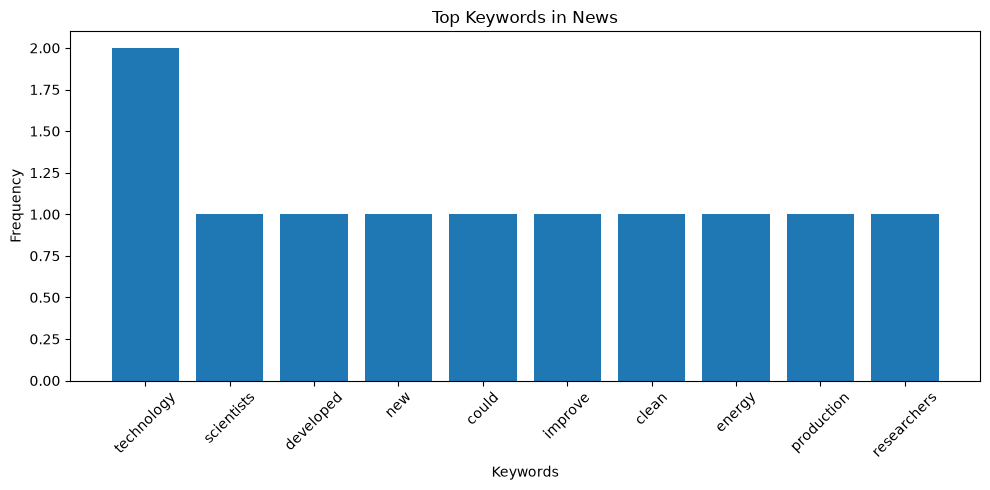

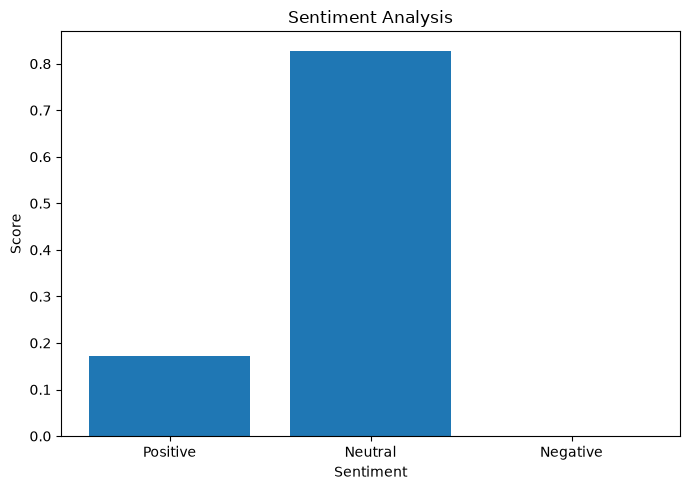

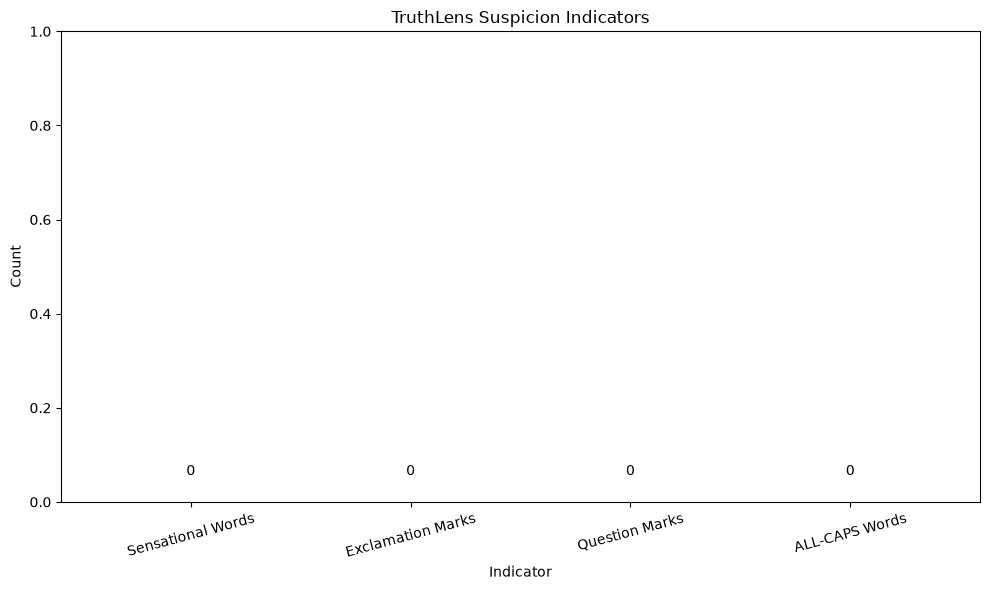


📊 Suspicion Indicator Values
-----------------------------------
Sensational Words: 0
Exclamation Marks: 0
Question Marks: 0
ALL-CAPS Words: 0


In [20]:
# ==========================================
# CELL 8 - TRUTHLENS CHARTS
# ==========================================

# ---------- CHART 1: TOP KEYWORDS ----------

if top_keywords:

    keyword_df = pd.DataFrame(
        top_keywords,
        columns=["Keyword", "Frequency"]
    )

    plt.figure(figsize=(10, 5))

    plt.bar(
        keyword_df["Keyword"],
        keyword_df["Frequency"]
    )

    plt.title("Top Keywords in News")
    plt.xlabel("Keywords")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("No keywords available for chart.")


# ---------- CHART 2: SENTIMENT ----------

positive_score = max(polarity, 0)
negative_score = max(-polarity, 0)
neutral_score = max(1 - abs(polarity), 0)

sentiment_labels = [
    "Positive",
    "Neutral",
    "Negative"
]

sentiment_values = [
    positive_score,
    neutral_score,
    negative_score
]

plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_labels,
    sentiment_values
)

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Score")

plt.tight_layout()
plt.show()


# ==========================================
# CELL 8 - TRUTHLENS SUSPICION INDICATOR
# ==========================================

indicator_names = [
    "Sensational Words",
    "Exclamation Marks",
    "Question Marks",
    "ALL-CAPS Words"
]

indicator_values = [
    suspicious_word_count,
    exclamation_count,
    question_count,
    uppercase_count
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    indicator_names,
    indicator_values
)

plt.title("TruthLens Suspicion Indicators")
plt.xlabel("Indicator")
plt.ylabel("Count")

# Make the chart visible even when all values are 0
maximum = max(indicator_values)

if maximum == 0:
    plt.ylim(0, 1)
else:
    plt.ylim(0, maximum + 1)

# Show value above each bar
for bar, value in zip(bars, indicator_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        str(value),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Print the actual values too
print("\n📊 Suspicion Indicator Values")
print("-" * 35)

for name, value in zip(indicator_names, indicator_values):
    print(f"{name}: {value}")


In [21]:
# ==========================================
# CELL 9 - FINAL TRUTHLENS REPORT
# ==========================================

print("\n")
print("=" * 60)
print("              TRUTHLENS FINAL REPORT")
print("=" * 60)

print(f"\n📰 News Analysis")
print("-" * 60)

print(f"Word Count          : {word_count}")
print(f"Sentence Count      : {sentence_count}")
print(f"Character Count     : {character_count}")
print(f"Average Word Length : {average_word_length:.2f}")

print("\n😊 Sentiment Analysis")
print("-" * 60)

print(f"Sentiment            : {sentiment}")
print(f"Polarity             : {polarity:.2f}")
print(f"Subjectivity         : {subjectivity:.2f}")

print("\n🔑 Top Keywords")
print("-" * 60)

if top_keywords:
    for number, (word, count) in enumerate(top_keywords[:5], start=1):
        print(f"{number}. {word} ({count})")
else:
    print("No keywords found.")

print("\n⚠️ Suspicion Analysis")
print("-" * 60)

print(f"Suspicion Score      : {score}/100")
print(f"Suspicion Level      : {suspicion_level}")
print(f"Sensational Words    : {suspicious_word_count}")
print(f"Exclamation Marks    : {exclamation_count}")
print(f"Question Marks       : {question_count}")
print(f"ALL-CAPS Words       : {uppercase_count}")

print("\n" + "=" * 60)
print("                  CONCLUSION")
print("=" * 60)

if score < 20:
    conclusion = "The text contains relatively few sensational language patterns."
elif score < 50:
    conclusion = "The text contains some attention-grabbing language patterns."
else:
    conclusion = "The text contains several attention-grabbing language patterns."

print("\n" + conclusion)

print("\nImportant:")
print("TruthLens analyzes linguistic patterns.")
print("It does NOT prove that the news is true or false.")

print("\n" + "=" * 60)
print("        ✅ TRUTHLENS ANALYSIS COMPLETED")
print("=" * 60)



              TRUTHLENS FINAL REPORT

📰 News Analysis
------------------------------------------------------------
Word Count          : 36
Sentence Count      : 3
Character Count     : 248
Average Word Length : 5.83

😊 Sentiment Analysis
------------------------------------------------------------
Sentiment            : Positive 😊
Polarity             : 0.17
Subjectivity         : 0.41

🔑 Top Keywords
------------------------------------------------------------
1. technology (2)
2. scientists (1)
3. developed (1)
4. new (1)
5. could (1)

⚠️ Suspicion Analysis
------------------------------------------------------------
Suspicion Score      : 0/100
Suspicion Level      : LOW 🟢
Sensational Words    : 0
Exclamation Marks    : 0
Question Marks       : 0
ALL-CAPS Words       : 0

                  CONCLUSION

The text contains relatively few sensational language patterns.

Important:
TruthLens analyzes linguistic patterns.
It does NOT prove that the news is true or false.

        ✅ TRUT